# Phishing Websites from UCI 

## Random Forest

### 1. Import Libraries

In [1]:
from sklearn.metrics import accuracy_score,precision_score,f1_score,confusion_matrix,roc_curve,auc,roc_auc_score,recall_score,ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from ucimlrepo import fetch_ucirepo
import time,joblib
import tracemalloc 
import pandas as pd
import matplotlib.pyplot as plt

### 2. Load Dataset

In [2]:
phishing = fetch_ucirepo(id=327)
x=phishing.data.features
y=phishing.data.targets.values.ravel()
print(f"Dataset loaded: {x.shape[0]} samples, {x.shape[1]} features")

Dataset loaded: 11055 samples, 30 features


### 3. Train-Test Split

In [3]:
x_trn, x_tst , y_trn, y_tst = train_test_split(x,y,test_size=0.3,random_state=42)

### 4. Preprocessing — StandardScaler

In [4]:
scaler = joblib.load("scaler.pkl")
x_trn = scaler.transform(x_trn)
x_tst = scaler.transform(x_tst)


### 5. Train Model — Random Foredst

In [5]:
rF = RandomForestClassifier(n_estimators=50,max_depth=5,random_state=42)
rF.fit(x_trn,y_trn)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",50
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_t

In [6]:
start=time.time()
y_pred=rF.predict(x_tst)
time1=time.time() - start
print("Random Forest Prediction time:", time1)


Random Forest Prediction time: 0.021906137466430664


In [7]:
tracemalloc.start()
_ = rF.predict(x_tst)
current_mem, peak_mem = tracemalloc.get_traced_memory()
tracemalloc.stop()
print(f"Memory Usage (current): {current_mem / 1024:.2f} KB")
print(f"Memory Usage (peak):    {peak_mem / 1024:.2f} KB")

Memory Usage (current): 36.43 KB
Memory Usage (peak):    533.85 KB


In [8]:
joblib.dump(rF,"rFModel.pkl")
print("Model saved as rfModel.pkl")
joblib.dump(list(x.columns), "feature_names.pkl")
print("Feature names saved as feature_names.pkl")

Model saved as rfModel.pkl
Feature names saved as feature_names.pkl


### 6. Overfitting Check

In [9]:
train_accuracy = rF.score(x_trn, y_trn)
test_accuracy  = accuracy_score(y_tst, y_pred)

print(f"Training Accuracy : {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")
print(f"Test Accuracy     : {test_accuracy:.4f}  ({test_accuracy*100:.2f}%)")
print(f"Difference        : {abs(train_accuracy - test_accuracy):.4f}")

if abs(train_accuracy - test_accuracy) < 0.02:
    print("Status            : No Overfitting (difference < 2%)")
elif abs(train_accuracy - test_accuracy) < 0.05:
    print("Status            : Slight Overfitting (difference 2-5%)")
else:
    print("Status            : Overfitting detected (difference > 5%)")

Training Accuracy : 0.9284 (92.84%)
Test Accuracy     : 0.9292  (92.92%)
Difference        : 0.0007
Status            : No Overfitting (difference < 2%)


### 7. EVALUATION METRICS

In [10]:
accuuracy = accuracy_score(y_tst,y_pred)
precision=precision_score(y_tst,y_pred)
f1score=f1_score(y_tst,y_pred)
recall    = recall_score(y_tst, y_pred)
confusionMatrix=confusion_matrix(y_tst,y_pred)

In [11]:
print("Accuracy = ",accuuracy)
print(f"Precision = {precision:.4f} ({precision*100:.2f}%)")
print(f"Recall    = {recall:.4f}  ({recall*100:.2f}%)")
print("F1 Score = ",f1score)
print(f"Prediction Time : {time1:.6f} sec")
print(f"Peak Memory     : {peak_mem / 1024:.2f} KB")

Accuracy =  0.9291528489599036
Precision = 0.9272 (92.72%)
Recall    = 0.9502  (95.02%)
F1 Score =  0.938562091503268
Prediction Time : 0.021906 sec
Peak Memory     : 533.85 KB


In [12]:
print("Confusion Matrix : \n",confusionMatrix)

Confusion Matrix : 
 [[1287  141]
 [  94 1795]]


In [13]:
y_prob = rF.predict_proba(x_tst)[:,1]
fpr, tpr, _ = roc_curve(y_tst, y_prob)
roc_auc = auc(fpr, tpr)
print(f"\nROC-AUC Score = {roc_auc:.4f}")


ROC-AUC Score = 0.9807


### 8. ROC CURVE + AUC

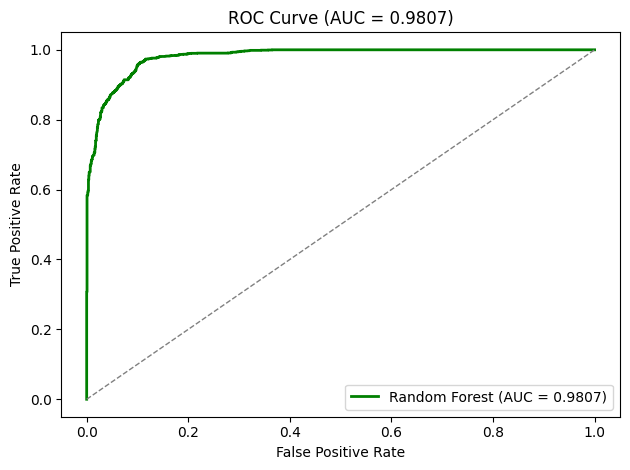

In [14]:
plt.plot(fpr, tpr, color='green', lw=2, label=f"Random Forest (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (AUC = %0.4f)" % roc_auc)
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("roc_random_forest.png", dpi=150)
plt.show()

### 9. Summary Table

In [15]:
summary = pd.DataFrame({
    "Model": ["Random Forest"],
    "Accuracy (%)":  [round(accuuracy * 100, 2)],
    "Precision (%)": [round(precision * 100, 2)],
    "Recall (%)":    [round(recall * 100, 2)],
    "F1-Score (%)":  [round(f1score * 100, 2)],
    "ROC-AUC":       [round(roc_auc, 4)],
    "Pred Time (s)": [round(time1, 6)],
    "Peak Mem (KB)": [round(peak_mem / 1024, 2)]
})


print(summary.to_string(index=False))


        Model  Accuracy (%)  Precision (%)  Recall (%)  F1-Score (%)  ROC-AUC  Pred Time (s)  Peak Mem (KB)
Random Forest         92.92          92.72       95.02         93.86   0.9807       0.021906         533.85
